In [1]:
from RCENSO import *
import numpy as np
import xarray as xr
rpy.verbosity(0)
from XRO import XRO
import pickle
%config InlineBackend.figure_format = 'retina'
import warnings
warnings.filterwarnings("ignore")

## 1. Configuration and Data Loading

Reproduce the mode-decoupling experiment (Fig. 3a–b). Each run removes one climate mode from the full 10-variable predictor set and measures the resulting degradation in Niño3.4 forecast skill for both DESN and XRO. Removing WWV causes the steepest drop in long-lead skill; other inter-basin modes contribute more modestly.

In [2]:
nmembers = 1
model_types=['DESN($n_l=1$)','DESN($n_l=2$)']

In [3]:
ds = xr.open_dataset('data\oras5_indices_1958-2025.nc',engine='netcdf4').sel(time=slice('1958-01', '2024-12'))
ds = standardize_time_to_month_start(ds)
ds = ds[['Nino34', 'WWV'] + [v for v in ds.data_vars if v not in ('Nino34', 'WWV')]]
TS = ds.to_array().values.T
tl = 42*12
TS_TP_anual = pack_TS_anualTP(TS,order=2)
t = np.arange(len(ds.time))

## 2. Hyperparameter Setup

Two DESN architectures are used: single-layer (20 000 units, IP reservoir) and two-layer (20 000 + 12 000 units). The `hypers` list is passed directly to `dimension_reduction_ensemble_forecast`, which trains both architectures for each leave-one-out variant.

In [4]:
hypers=[
    {
        'units':20000,
        'lr':1,
        'sr':1,
        'rc_connectivity':0.0,
        'input_connectivity':0.10,
        'input_scaling':1.0,
        'ridge':5e-6,
        'noise_rc':0.05,
        'noise_in':0,
        'seed': None,
        'use_raw_input':True,
        'ip_reservoir':True,
    },
    {
        'units':[20000,12000],
        'lr':[1,1],
        'sr':[1,1],
        'rc_connectivity':[0,0],
        'input_connectivity':[0.1,0.1],
        'input_scaling':[1.0,1.0],
        'ridge':5e-6,
        'noise_rc':[0.05,0],
        'noise_in':[0,0],
        'seed': None,
        'deep':True,
        'deep_ip_list':[True,False]
    },
]

## 3. DESN Mode Decoupling

`dimension_reduction_ensemble_forecast` trains a baseline model on all 10 modes, then trains 9 leave-one-out variants (each omitting one mode). `results` holds the raw ensemble forecasts; `results_mean` holds the ensemble-mean forecasts used for plotting.

In [ ]:
results, results_mean = dimension_reduction_ensemble_forecast(
    ds, tl=tl, wl=0, hypers=hypers, 
    exclude_dims=1, nmembers=nmembers,
    steps=20,
)

Configuration: 2 hyperparameter sets × 1 members = 2 total members

Training baseline model (all variables)...


Training ensemble members:   0%|          | 0/1 [00:00<?, ?it/s]

Layer 1: units=20000, sr=1, lr=1, ip_reservoir=True
Layer 2: units=12000, sr=1, lr=1, ip_reservoir=False


Forecasting with ensemble: 100%|██████████| 2/2 [02:00<00:00, 60.06s/it]


✓ Baseline completed (dim=10, total_members=2)

Testing 9 combinations (excluding 1 variable(s))...


...

Training ensemble members: 100%|██████████| 1/1 [00:27<00:00, 27.44s/it]


Layer 1: units=20000, sr=1, lr=1, ip_reservoir=True
Layer 2: units=12000, sr=1, lr=1, ip_reservoir=False


Training ensemble members: 100%|██████████| 1/1 [00:27<00:00, 27.59s/it]


Layer 1: units=20000, sr=1, lr=1, ip_reservoir=True
Layer 2: units=12000, sr=1, lr=1, ip_reservoir=False


Exclude 1 var(s): 100%|██████████| 9/9 [43:37<00:00, 290.88s/it]


## 4. XRO Mode Decoupling

The same leave-one-out experiment is run with the XRO model via `dimension_decoupling_xro_forecast`. This provides the physics-based baseline for quantifying how much each mode contributes to predictability (Fig. 3a).

In [6]:
# XRO model decoupling experiments
xro_model = XRO(ncycle=12, ac_order=2, is_forward=True)
xro_results = dimension_decoupling_xro_forecast(
    ds, base_vars=['Nino34'],
    xro_model=xro_model,
    tl=slice('1958-01','1999-12'),
    exclude_dims=1
)


XRO Model - Mode Decoupling Experiment
Base variables (always retained): Nino34
Decoupling pool: ['WWV', 'NPMM', 'SPMM', 'IOB', 'TNA', 'ATL3', 'IOD', 'SIOD', 'SASD']
Excluding 1 variable(s) at a time

Running baseline (Nino34+WWV+NPMM+SPMM+IOB+TNA+ATL3+IOD+SIOD+SASD)...
✓ Baseline completed (dim=10)

Testing 9 combinations (excluding 1 variable(s))...


Exclude 1 var(s): 100%|██████████| 9/9 [00:24<00:00,  2.74s/it]


✓ Completed 10 experiments
  - 1 baseline (dim=10)
  - 9 decoupling tests (dim=9 each)


## 5. Compute Forecast Skill

Compute Pearson correlation vs. lead time for each leave-one-out configuration. `calculate_ensemble_skill` handles the full ensemble; `ndforecast_skill` is used for the ensemble-mean and XRO outputs. Results are keyed by the removed mode name (or `'baseline'`).

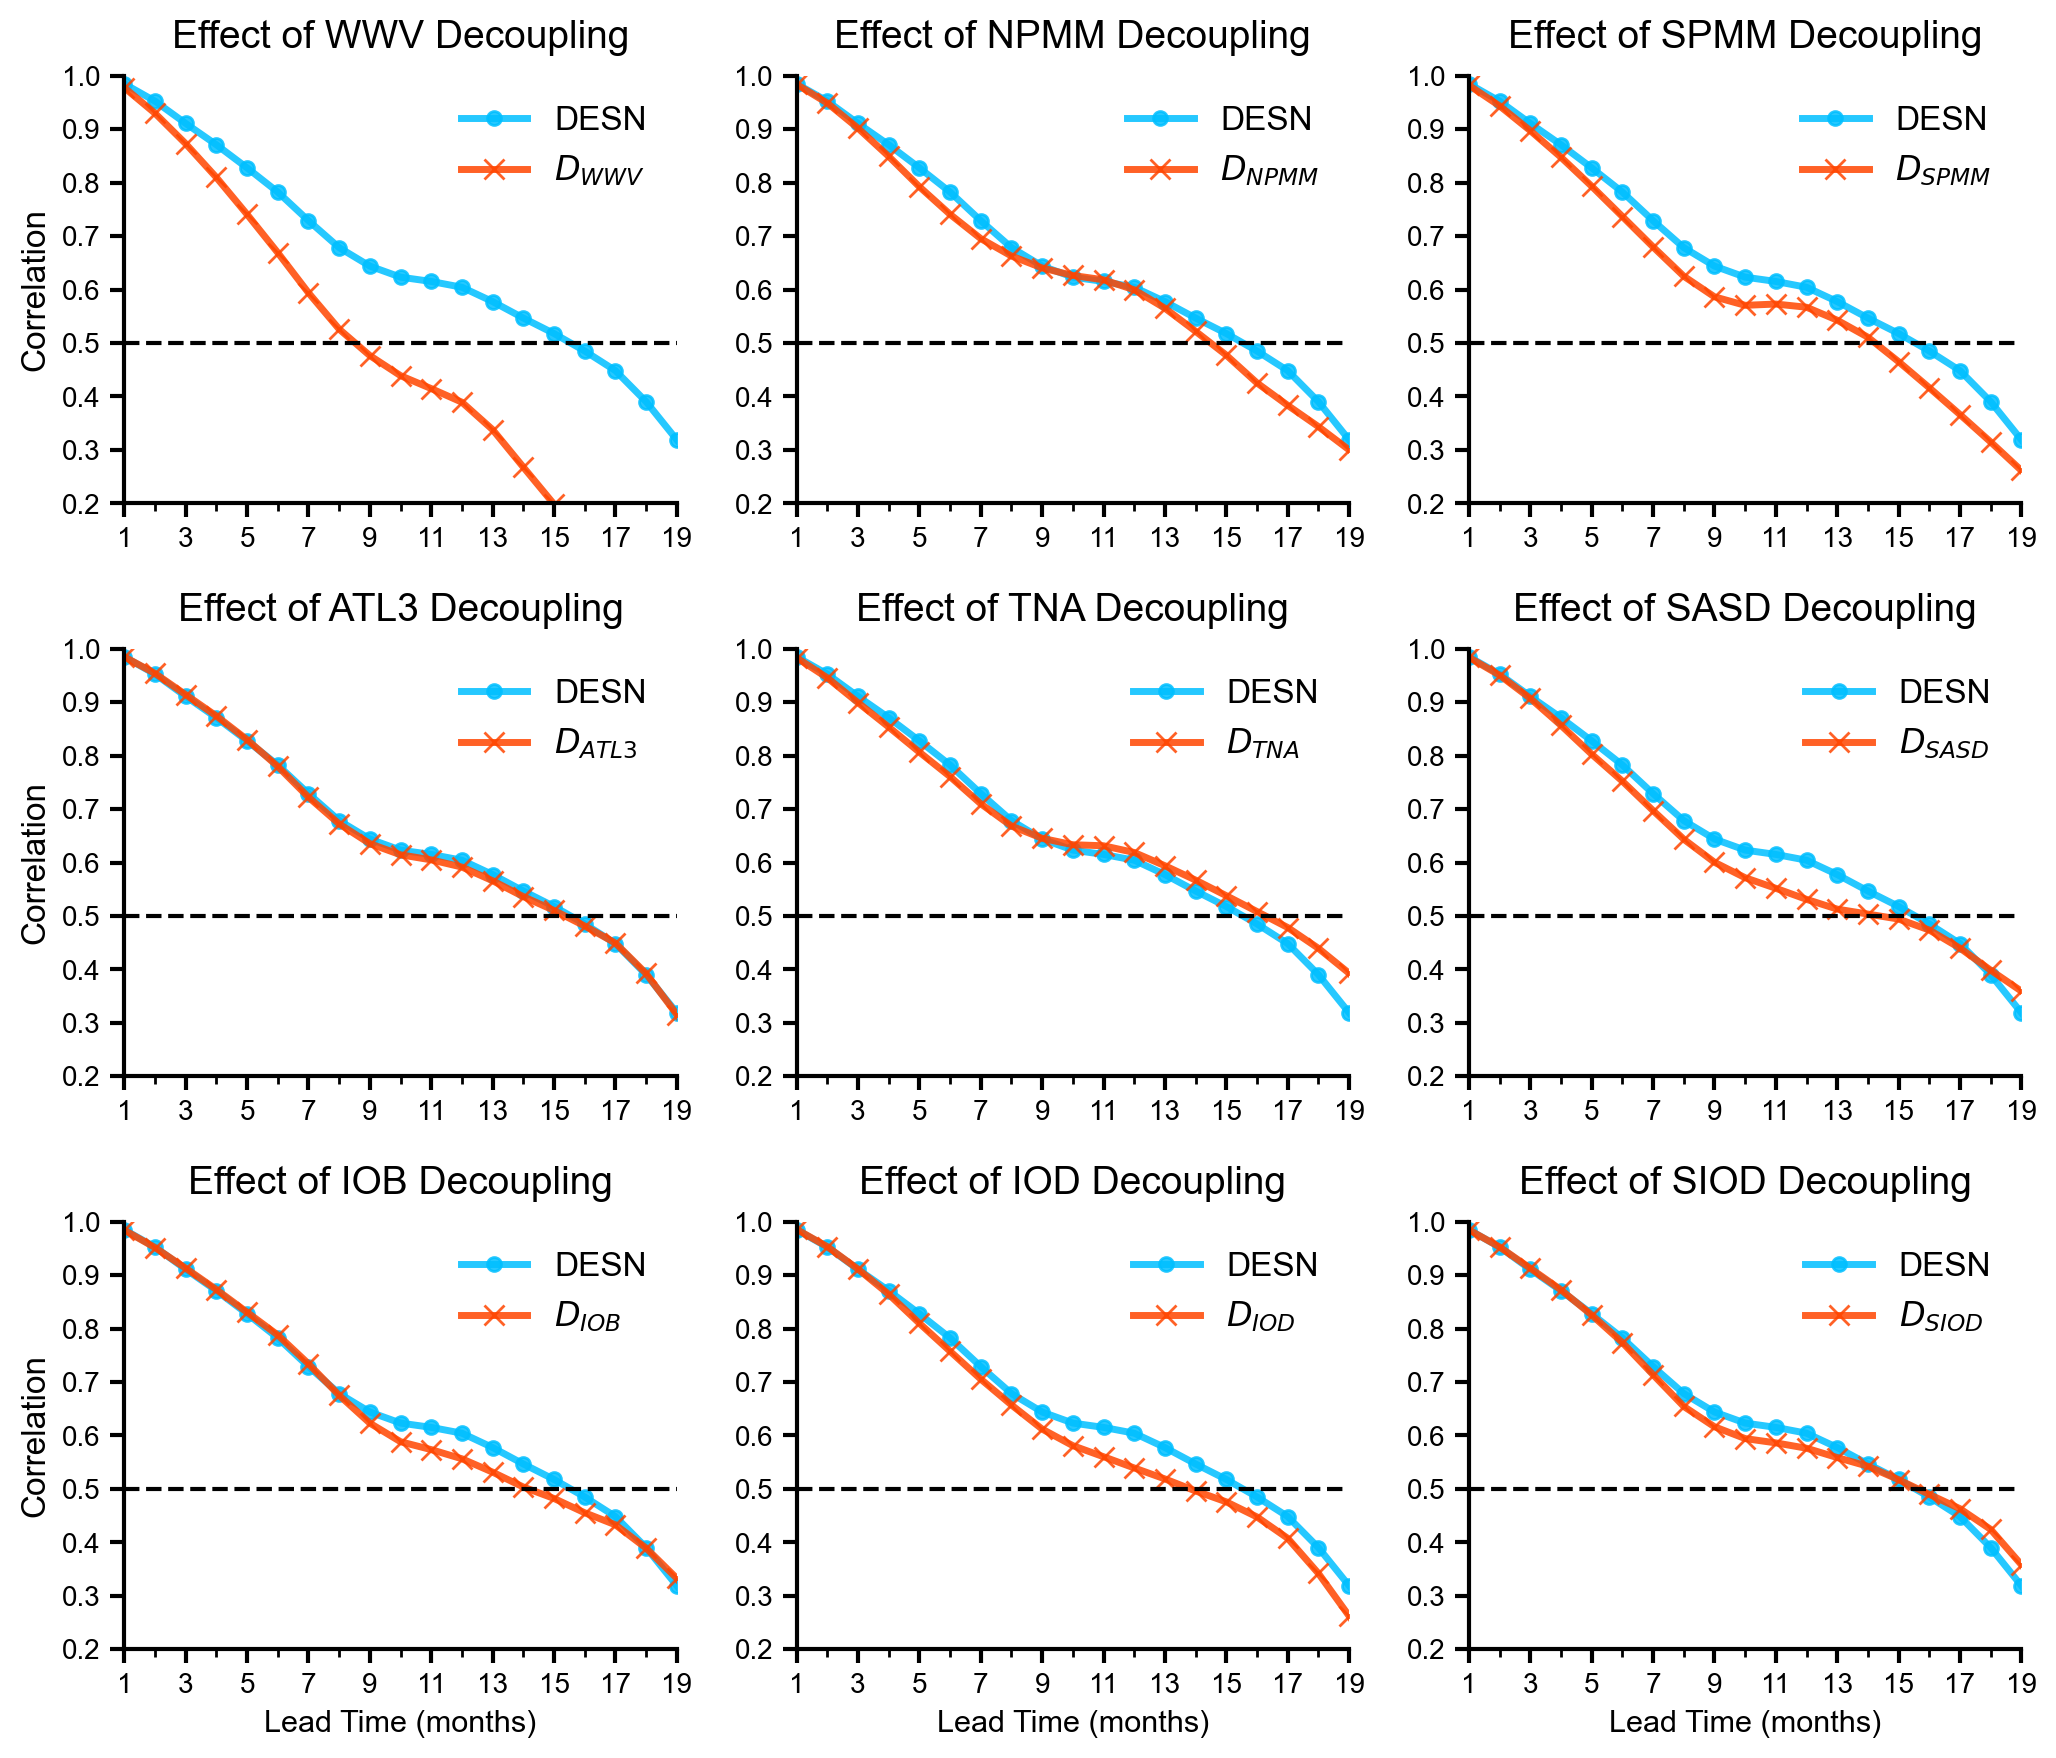

In [7]:
ds_test = ds.sel(time=slice('2000-01','2024-12'))
Ytest = ds_test.to_array().values.T
R = {}
rmse = {}

keys = ['baseline','WWV','NPMM','SPMM','ATL3','TNA','SASD','IOB','IOD','SIOD']
results_mean = reorder_and_rename_results(results_mean, key_order=keys)
for mode in results_mean.keys():
    if mode == 'baseline':
        R[mode],rmse[mode] = ndforecast_skill(results_mean[mode],Ytest,wl=24,plot=False)
    else:
        R[mode],rmse[mode] = ndforecast_skill(results_mean[mode],Ytest,wl=24,plot=False)

fig = visualize_skill_vs_baseline(R, ref_line=0.5)

In [ ]:
ds_test = ds.sel(time=slice('2000-01','2024-12'))
Ytest = ds_test.to_array().values.T
R = {}
rmse = {}

keys = ['baseline','WWV','NPMM','SPMM','ATL3','TNA','SASD','IOB','IOD','SIOD']
results = reorder_and_rename_results(results, key_order=keys)
R, rmse = calculate_ensemble_skill(
    results, Ytest, wl=36, showdim=0, ismv3=True
)
R['baseline'], rmse['baseline'] = ndforecast_skill(results_mean['baseline'],Ytest,wl=36,plot=False)

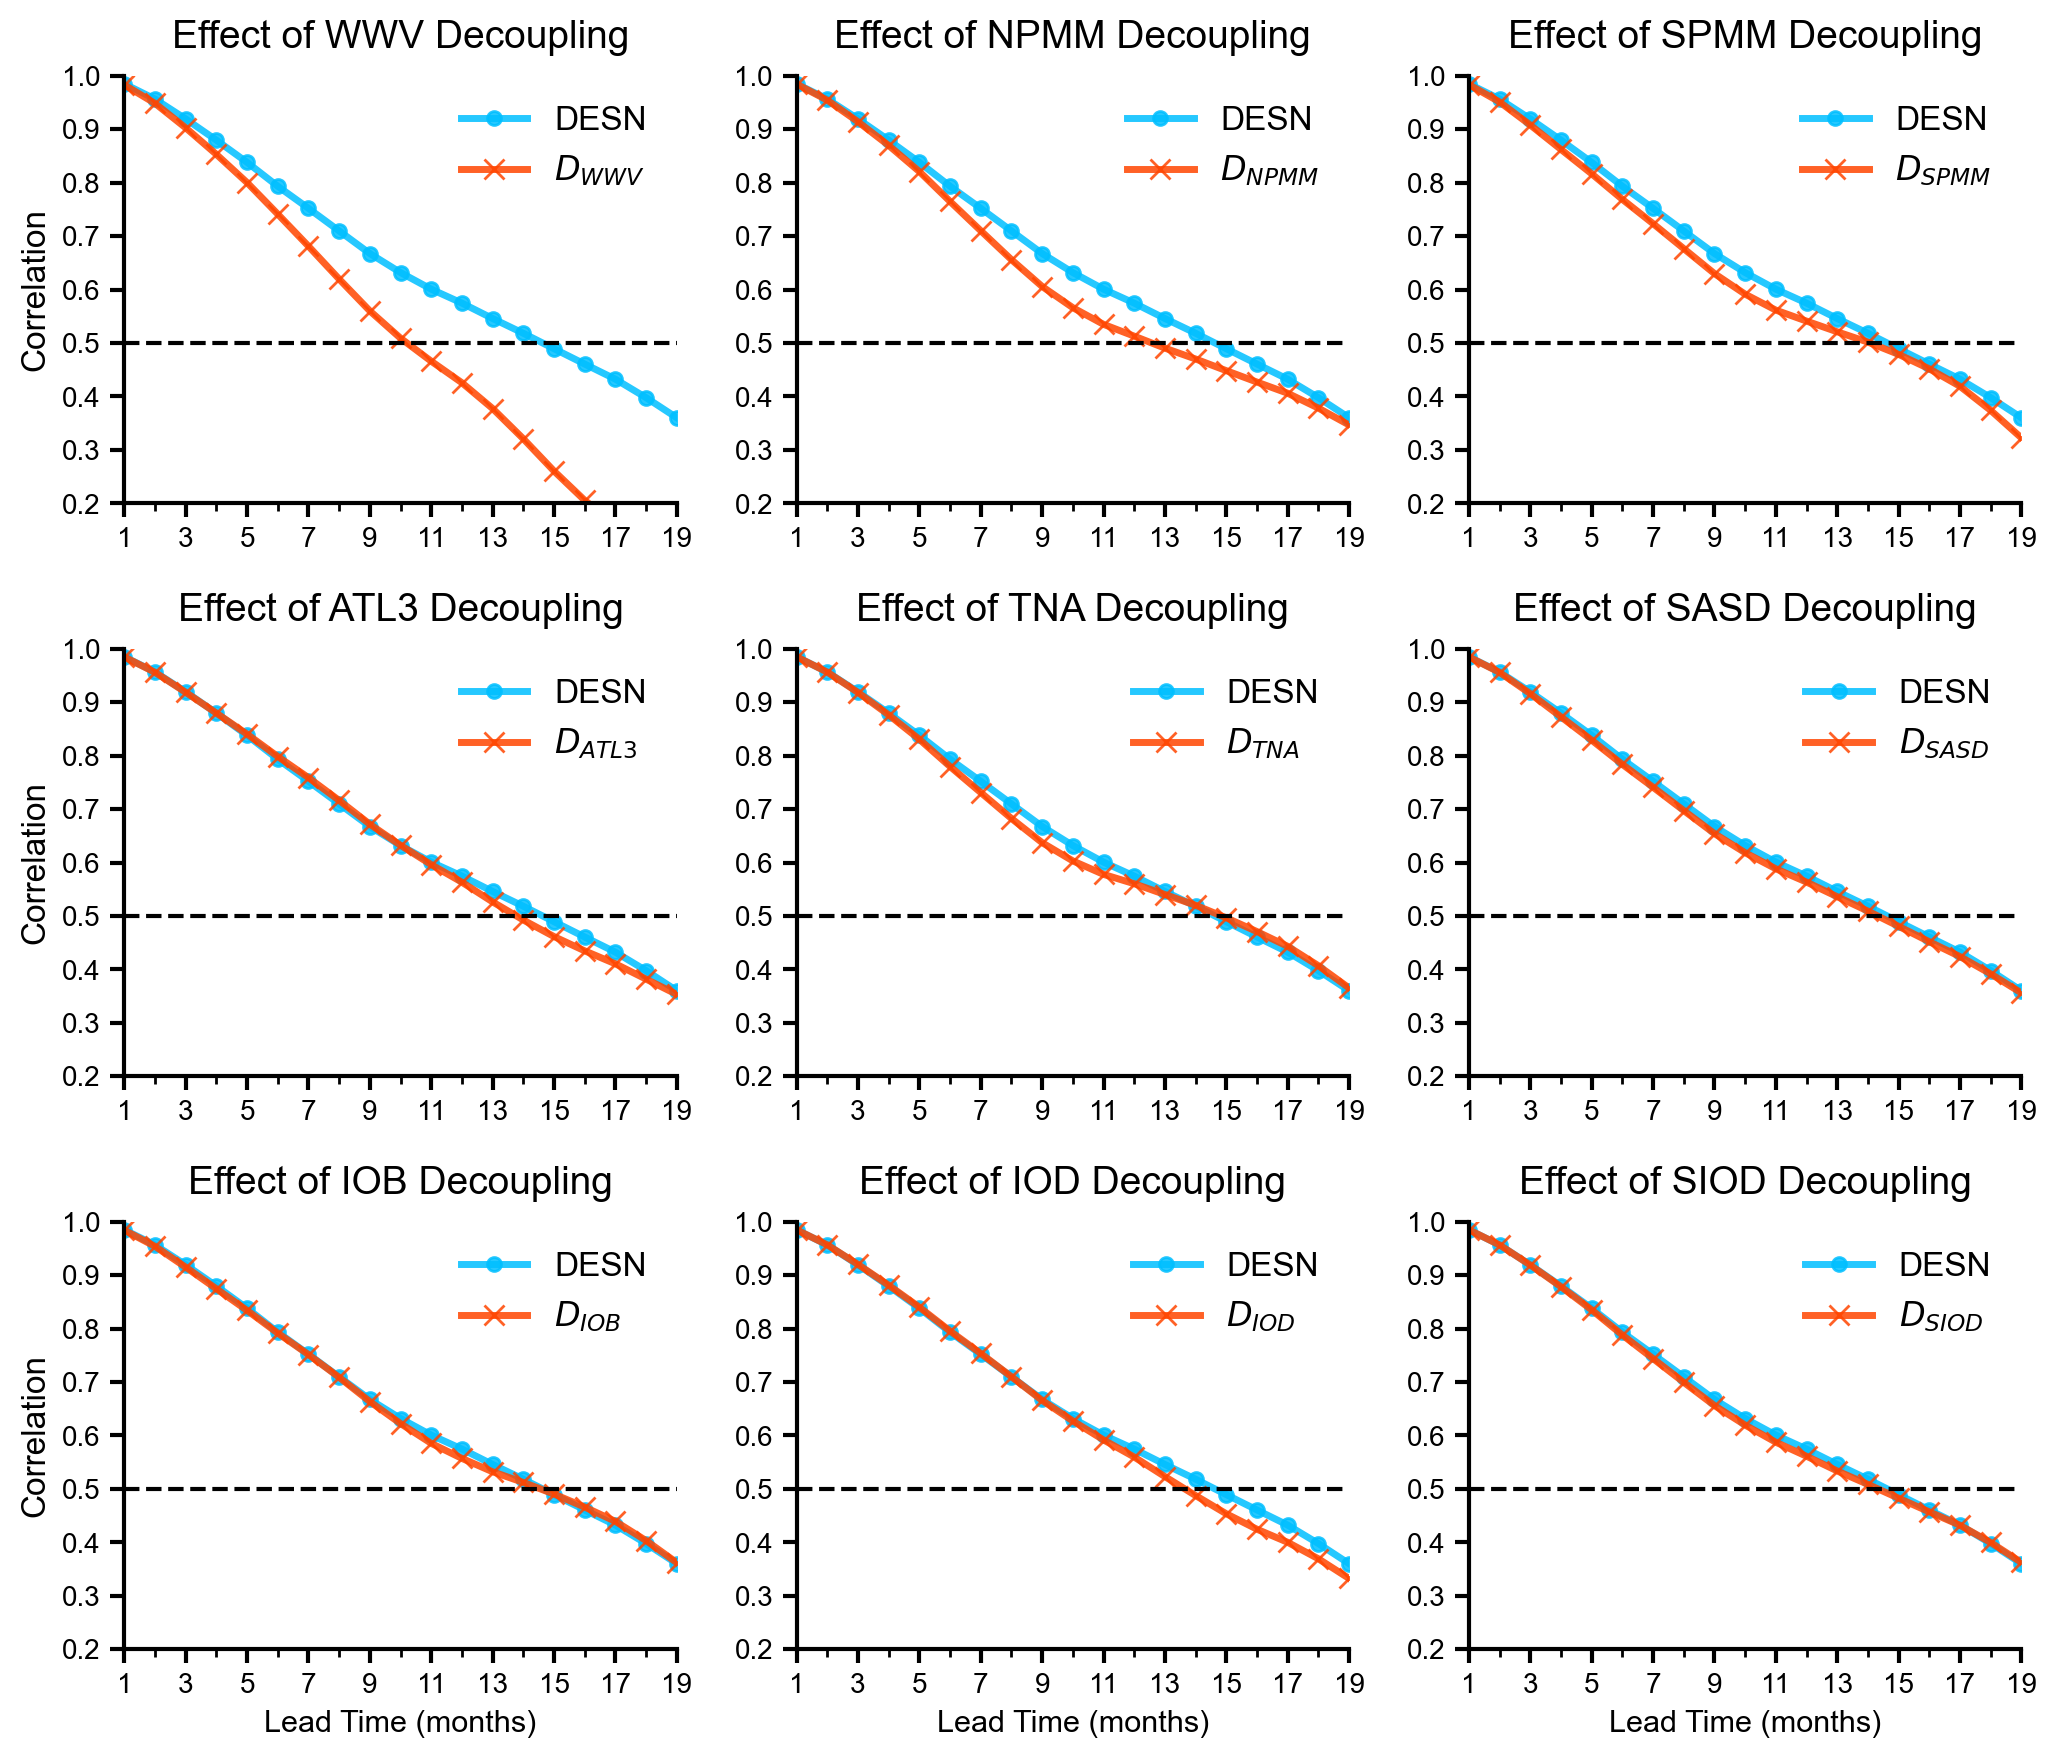

In [9]:
xro_results = reorder_and_rename_results(xro_results, key_order=keys)
R_xro = {}
rmse_xro = {}
for mode in xro_results.keys():
    R_xro[mode],rmse_xro[mode] = ndforecast_skill(xro_results[mode],Ytest,wl=36,plot=False)

fig = visualize_skill_vs_baseline(R_xro, ref_line=0.5)

## 6. Visualize Comparison (Fig. 3a–b)

`visualize_skill_comparison_vs_baseline` plots the skill change ΔR when each mode is removed, side-by-side for XRO (Fig. 3a) and DESN (Fig. 3b). A larger negative bar indicates that mode contributes more to forecast skill.

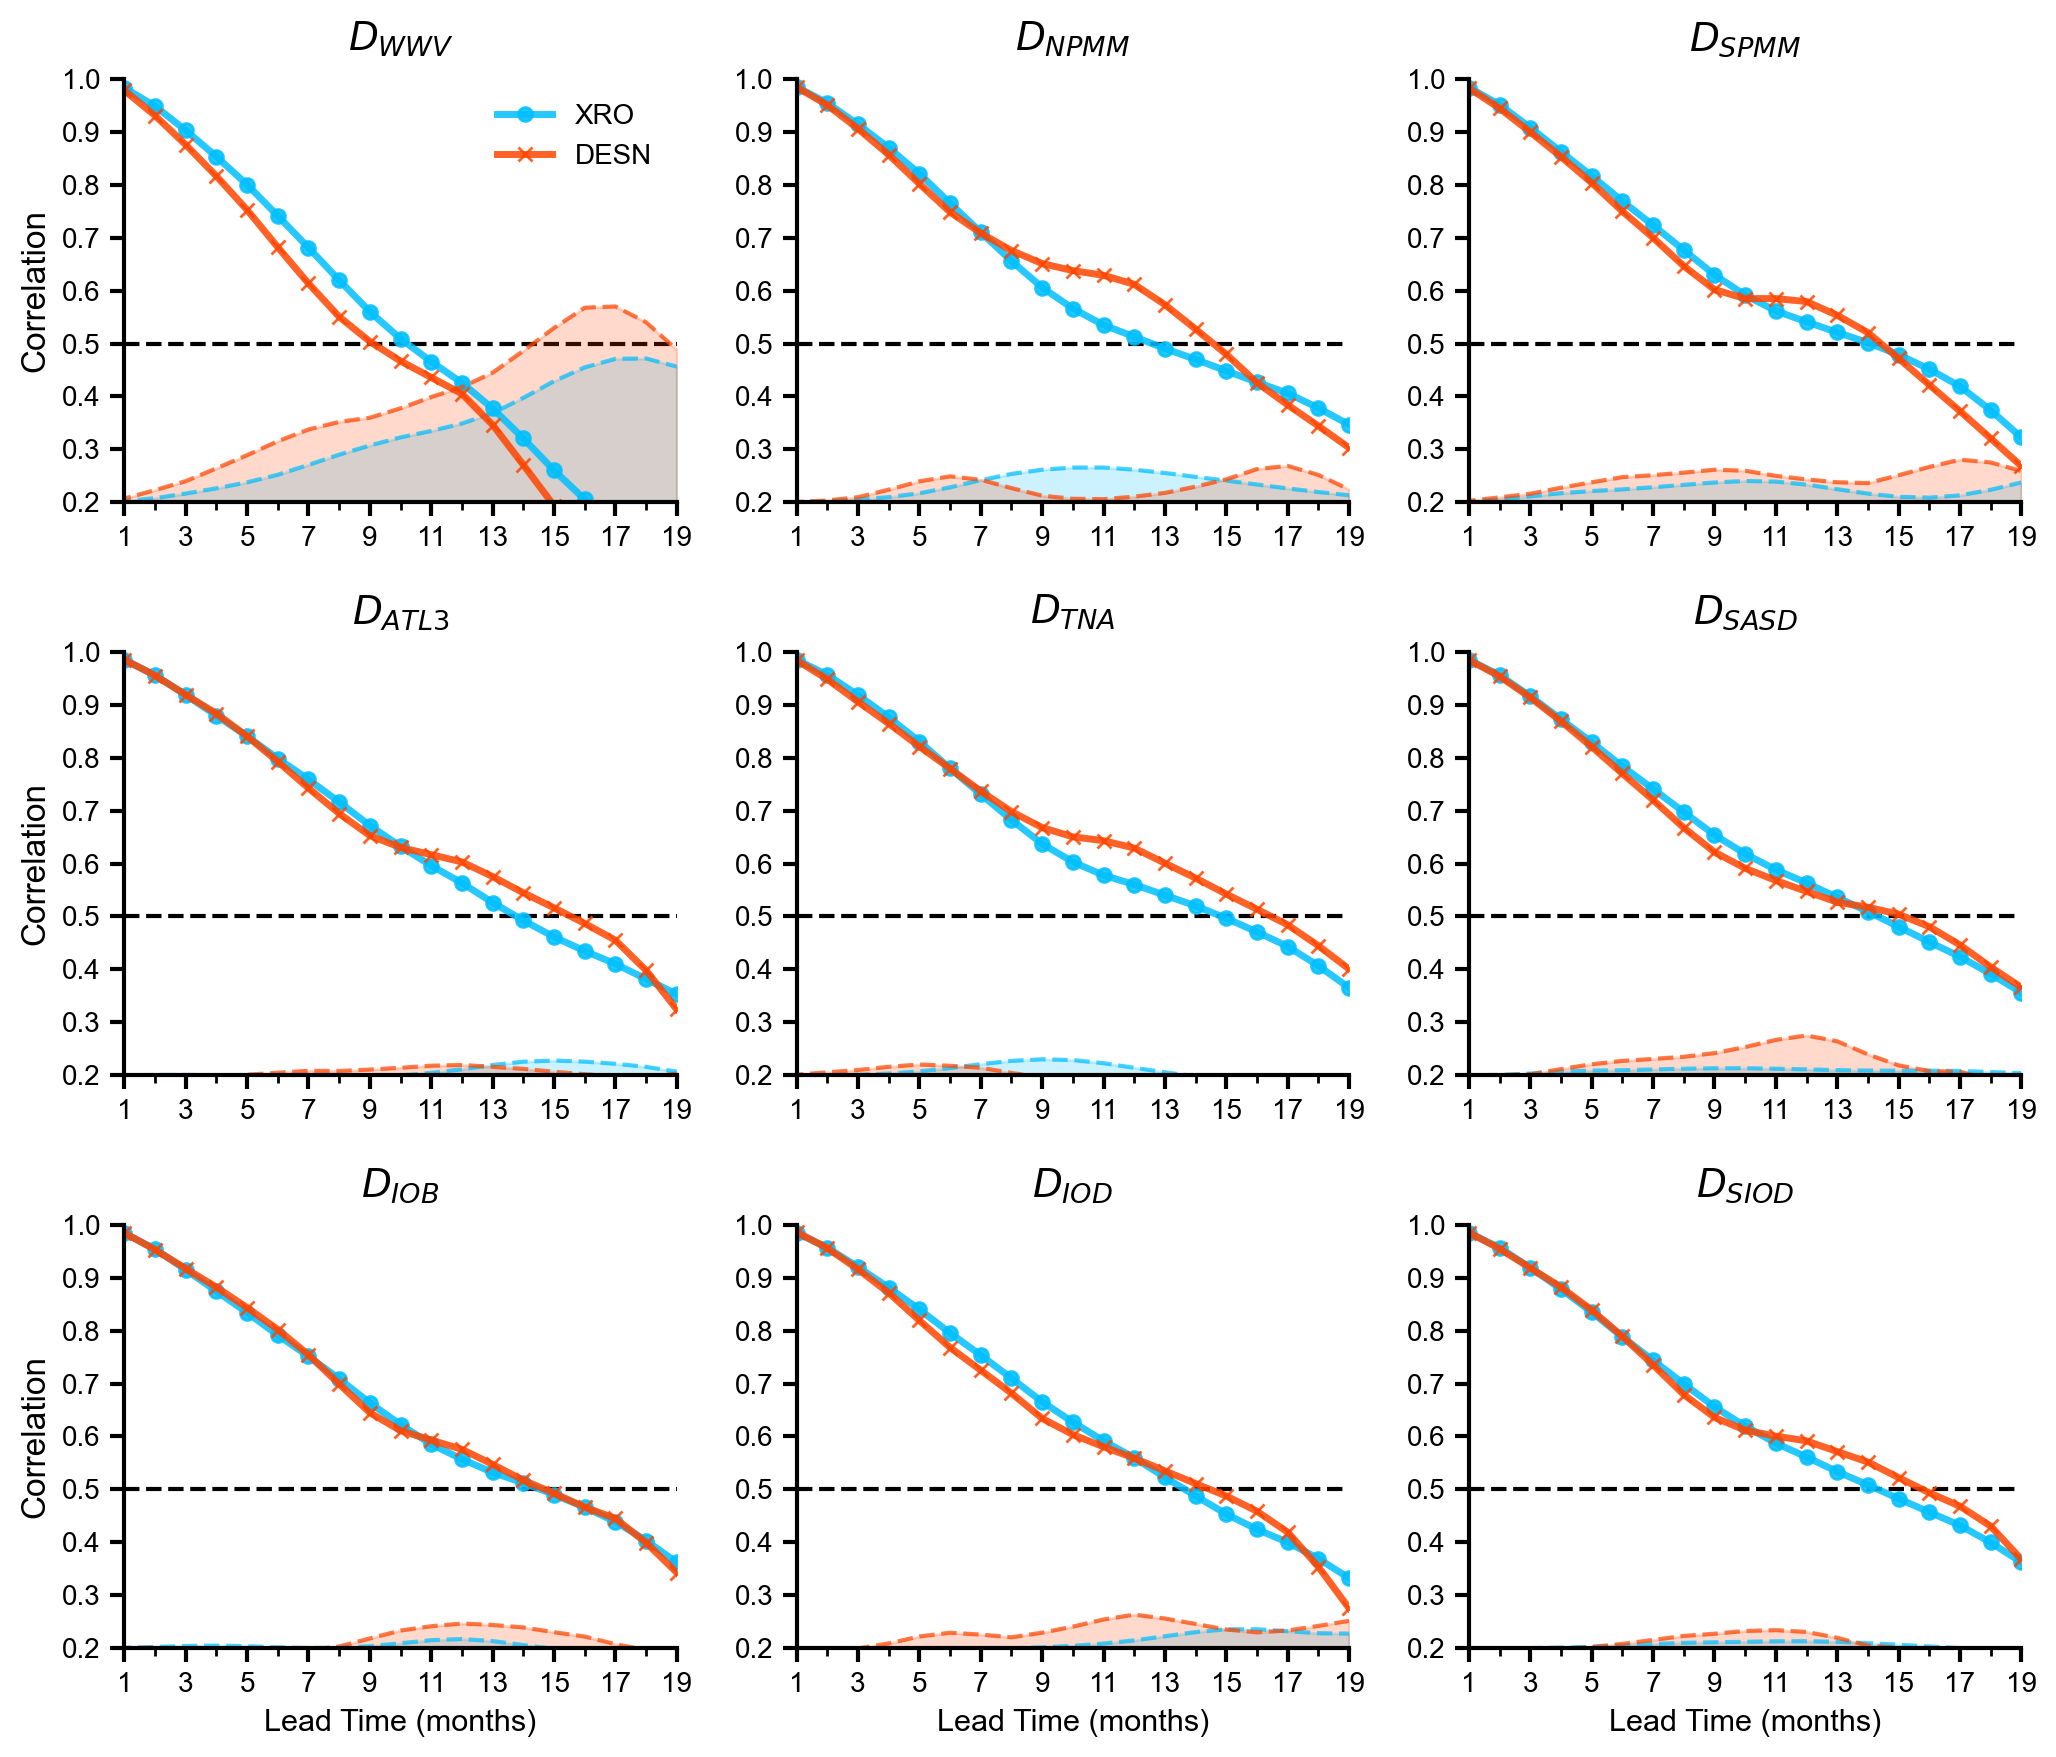

In [32]:
comparison_skill = {
    'XRO': R_xro,
    'DESN': R,
}
fig = visualize_skill_comparison_vs_baseline(comparison_skill,ref_line=0.5,show_difference=True)